In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from pathlib import Path
from matplotlib.ticker import MultipleLocator

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    HAS_LIFELINES = True
except ImportError:
    HAS_LIFELINES = False
    print("lifelines not installed. pip install lifelines")

Path("../results/figures").mkdir(parents=True, exist_ok=True)
Path("../results/tables").mkdir(parents=True, exist_ok=True)

# shared palette - pink shades for the LASSO models, teal for the neural nets
model_colors = {
    "mRNA-only LASSO":   "#c45b7f",
    "Multi-omics LASSO": "#9c224d",
    "mRNA-only NN":      "#65a3a1",
    "Multi-omics NN":    "#23716f",
}
ORDER = ["mRNA-only LASSO", "Multi-omics LASSO", "mRNA-only NN", "Multi-omics NN"]

In [14]:
# load the four models' fold-level CV results + the survival table
lasso_mrna  = pd.read_csv("../results/tables/lasso_cox_cv_results.csv")
lasso_multi = pd.read_csv("../results/tables/lasso_cox_multiomics_cv_results.csv")
nn_mrna     = pd.read_csv("../results/tables/nn_mRNA_only_best_model_folds.csv")
nn_multi    = pd.read_csv("../results/tables/nn_integrated_best_model_folds.csv")

surv = pd.read_csv("../data/processed/survival_luminal_clean.csv").set_index("patient")

lasso_mrna["model"]  = "mRNA-only LASSO"
lasso_multi["model"] = "Multi-omics LASSO"
nn_mrna["model"]     = "mRNA-only NN"
nn_multi["model"]    = "Multi-omics NN"

combined = pd.concat([lasso_mrna, lasso_multi, nn_mrna, nn_multi], ignore_index=True)
print("All four models loaded.")
print(combined.groupby("model")["test_c_index"].agg(["mean","std"]).round(3))

All four models loaded.
                    mean    std
model                          
Multi-omics LASSO  0.585  0.105
Multi-omics NN     0.640  0.195
mRNA-only LASSO    0.576  0.078
mRNA-only NN       0.621  0.056


In [15]:
# quick mean / sd / min / max of the C-index per model
summary = (
    combined.groupby("model")["test_c_index"]
    .agg(mean="mean", std="std", min="min", max="max")
    .round(3)
    .reset_index()
)
summary["model"] = pd.Categorical(summary["model"], categories=ORDER, ordered=True)
summary = summary.sort_values("model").reset_index(drop=True)
summary.to_csv("../results/tables/all_models_performance_summary.csv", index=False)
print(summary.to_string(index=False))

            model  mean   std   min   max
  mRNA-only LASSO 0.576 0.078 0.495 0.684
Multi-omics LASSO 0.585 0.105 0.432 0.701
     mRNA-only NN 0.621 0.056 0.563 0.710
   Multi-omics NN 0.640 0.195 0.311 0.831


/var/folders/d5/zw7r96yn5v19p1jp4jx0wg740000gn/T/ipykernel_46969/1694017791.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


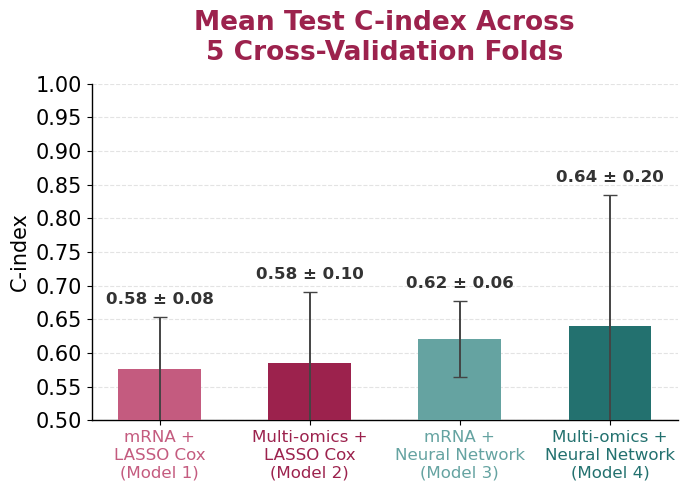

In [16]:
# bar chart: mean test C-index with SD whiskers
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    summary["model"],
    summary["mean"],
    color=[model_colors[m] for m in summary["model"]],
    width=0.55,
    edgecolor="none",
    zorder=3
)

ax.errorbar(
    summary["model"],
    summary["mean"],
    yerr=summary["std"],
    fmt="none",
    ecolor="#444444",
    elinewidth=1.4,
    capsize=5,
    zorder=4
)

for bar, (_, row) in zip(bars, summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        row["mean"] + row["std"] + 0.015,
        f'{row["mean"]:.2f} ± {row["std"]:.2f}',
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="#333333"
    )

ax.set_title(
    "Mean Test C-index Across\n5 Cross-Validation Folds",
    fontsize=19,
    fontweight="bold",
    color="#9c224d",
    pad=17
)

ax.tick_params(
    axis="both",
    which="both",
    labelsize=15
)

ax.set_ylabel("C-index", fontsize=15)

ax.set_ylim(0.50, 1)
ax.set_yticks(np.arange(0.50, 1.01, 0.05))

ax.yaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.set_xticklabels([
    "mRNA +\nLASSO Cox\n(Model 1)",
    "Multi-omics +\nLASSO Cox\n(Model 2)",
    "mRNA +\nNeural Network\n(Model 3)",
    "Multi-omics +\nNeural Network\n(Model 4)"
], fontsize=12)

for label, model in zip(ax.get_xticklabels(), summary["model"]):
    label.set_color(model_colors[model])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

plt.tight_layout()
plt.savefig("../results/figures/cindex_all_models_mean_sd.png", dpi=300)
plt.show()

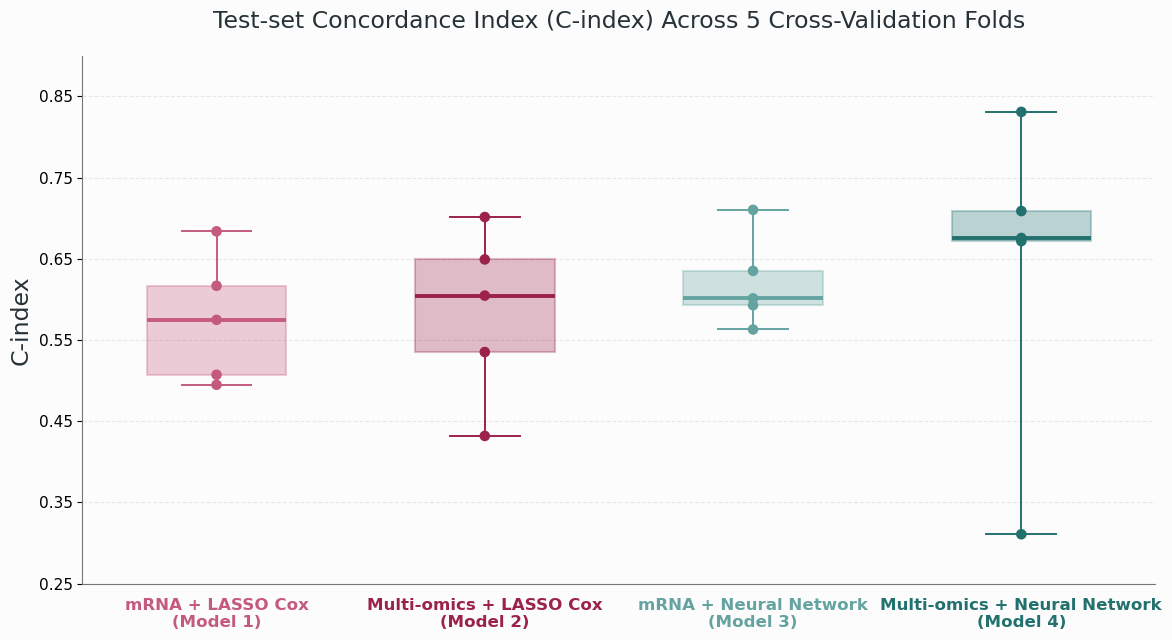

In [17]:
# full spread of the C-index across the 5 folds
model_order = [
    model for model in ORDER
    if model in combined["model"].unique()
]

display_labels = {
    "mRNA-only LASSO": "mRNA + LASSO Cox\n(Model 1)",
    "Multi-omics LASSO": "Multi-omics + LASSO Cox\n(Model 2)",
    "mRNA-only NN": "mRNA + Neural Network\n(Model 3)",
    "Multi-omics NN": "Multi-omics + Neural Network\n(Model 4)"
}

background = "#fcfcfc"
text_color = "#263238"

plot_data = [
    combined.loc[
        combined["model"] == model,
        "test_c_index"
    ].dropna().values
    for model in model_order
]

positions = np.arange(1, len(model_order) + 1)

fig, ax = plt.subplots(
    figsize=(12, 6.5),
    facecolor=background
)

ax.set_facecolor(background)

boxplot = ax.boxplot(
    plot_data,
    positions=positions,
    widths=0.52,
    patch_artist=True,
    showfliers=False,
    whis=(0, 100),
    medianprops=dict(
        linewidth=2.5
    ),
    whiskerprops=dict(
        linewidth=1.4
    ),
    capprops=dict(
        linewidth=1.4
    )
)

for i, model in enumerate(model_order):
    color = model_colors[model]

    boxplot["boxes"][i].set(
        facecolor=color,
        edgecolor=color,
        linewidth=1.5,
        alpha=0.30
    )

    boxplot["medians"][i].set(
        color=color,
        linewidth=2.8
    )

    for j in [2 * i, 2 * i + 1]:
        boxplot["whiskers"][j].set_color(color)
        boxplot["caps"][j].set_color(color)

for position, model, values in zip(
    positions,
    model_order,
    plot_data
):
    ax.scatter(
        np.full(len(values), position),
        values,
        s=58,
        color=model_colors[model],
        edgecolor="none",
        zorder=3
    )

ax.set_title(
    "Test-set Concordance Index (C-index) Across 5 Cross-Validation Folds",
    fontsize=17,
    color=text_color,
    pad=20
)

ax.tick_params(
    axis="both",
    which="both",
    labelsize=15
)

ax.set_ylabel(
    "C-index",
    fontsize=17,
    color=text_color
)

ax.set_xlabel("")

ax.set_xticks(positions)

ax.set_xticklabels(
    [display_labels[model] for model in model_order],
    fontsize=12,
    fontweight="bold"
)

for tick_label, model in zip(ax.get_xticklabels(), model_order):
    tick_label.set_color(model_colors[model])

all_values = combined["test_c_index"]

ymin = np.floor((all_values.min() - 0.02) * 20) / 20
ymax = np.ceil((all_values.max() + 0.02) * 20) / 20

ax.set_ylim(ymin, ymax)
ax.set_yticks(np.arange(ymin, ymax + 0.001, 0.1))

ax.tick_params(
    axis="y",
    labelsize=11
)

ax.tick_params(
    axis="x",
    length=0,
    pad=10
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    alpha=0.25
)

ax.xaxis.grid(False)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#777777")
ax.spines["bottom"].set_color("#777777")

plt.tight_layout()

plt.savefig(
    "../results/figures/cindex_all_models_boxplot.png",
    dpi=300,
    facecolor=background,
    bbox_inches="tight"
)

plt.show()

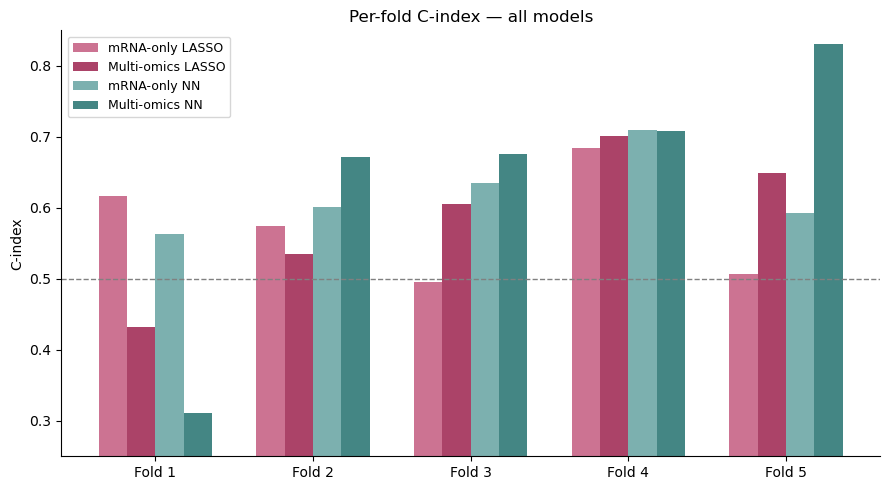

In [18]:
# same scores again, this time broken out fold by fold
fig, ax = plt.subplots(figsize=(9, 5))
n_models = len(model_order)
width = 0.18
x = np.arange(1, 6)

for i, model in enumerate(model_order):
    subset = combined[combined["model"] == model].sort_values("fold")
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, subset["test_c_index"], width,
           label=model, color=model_colors[model], alpha=0.85)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {f}" for f in range(1, 6)])
ax.set_ylabel("C-index")
ax.set_title("Per-fold C-index — all models")
ax.set_ylim(0.25, 0.85)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/cindex_per_fold_all_models.png", dpi=300)
plt.show()

                   Mean     SD  Min    Max  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
Model                                                                             
Multi-omics LASSO  82.2  126.6  1.0  294.0     1.0     5.0   107.0     4.0   294.0
mRNA-only LASSO    13.8   11.6  5.0   33.0    16.0     5.0     9.0    33.0     6.0


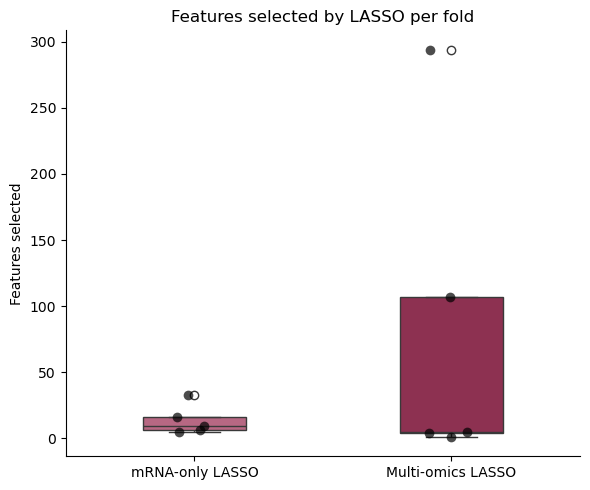

In [19]:
# how stable is LASSO's feature count from fold to fold?
lasso_only = combined[combined["model"].isin(["mRNA-only LASSO", "Multi-omics LASSO"])]

feat_pivot = lasso_only.pivot(index="model", columns="fold", values="n_features_selected")
feat_pivot.columns = [f"Fold {c}" for c in feat_pivot.columns]
feat_pivot.insert(0, "Mean", feat_pivot.mean(axis=1).round(1))
feat_pivot.insert(1, "SD",   lasso_only.groupby("model")["n_features_selected"].std().round(1))
feat_pivot.insert(2, "Min",  lasso_only.groupby("model")["n_features_selected"].min())
feat_pivot.insert(3, "Max",  lasso_only.groupby("model")["n_features_selected"].max())
feat_pivot.index.name = "Model"
print(feat_pivot.to_string())

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=lasso_only, x="model", y="n_features_selected",
            hue="model",
            palette={"mRNA-only LASSO": model_colors["mRNA-only LASSO"],
                     "Multi-omics LASSO": model_colors["Multi-omics LASSO"]},
            legend=False, width=0.4, ax=ax)
sns.stripplot(data=lasso_only, x="model", y="n_features_selected",
              color="black", alpha=0.7, size=7, ax=ax)
ax.set_title("Features selected by LASSO per fold")
ax.set_xlabel("")
ax.set_ylabel("Features selected")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/feature_selection_stability.png", dpi=300)
plt.show()

In [20]:
# paired Wilcoxon on the fold C-indices
pairs = [
    ("mRNA-only LASSO",   "Multi-omics LASSO",  "Does methylation help in LASSO?"),
    ("mRNA-only NN",      "Multi-omics NN",      "Does methylation help in NN?"),
    ("mRNA-only LASSO",   "mRNA-only NN",        "Does NN beat LASSO on RNA only?"),
    ("Multi-omics LASSO", "Multi-omics NN",      "Does NN beat LASSO with both omics?"),
]

wilcoxon_rows = []
for m1, m2, question in pairs:
    s1 = combined.loc[combined["model"] == m1, "test_c_index"].values
    s2 = combined.loc[combined["model"] == m2, "test_c_index"].values
    stat, pval = wilcoxon(s1, s2)
    sig = "yes" if pval < 0.05 else "no"
    wilcoxon_rows.append({"comparison": question, "model_1": m1, "model_2": m2,
                          "statistic": round(stat, 3), "p_value": round(pval, 4),
                          "significant": sig})
    print(f"{question}: p={pval:.4f} ({'significant' if pval < 0.05 else 'not significant'})")

pd.DataFrame(wilcoxon_rows).to_csv(
    "../results/tables/wilcoxon_model_comparisons.csv", index=False)

Does methylation help in LASSO?: p=1.0000 (not significant)
Does methylation help in NN?: p=0.8125 (not significant)
Does NN beat LASSO on RNA only?: p=0.3125 (not significant)
Does NN beat LASSO with both omics?: p=0.3125 (not significant)


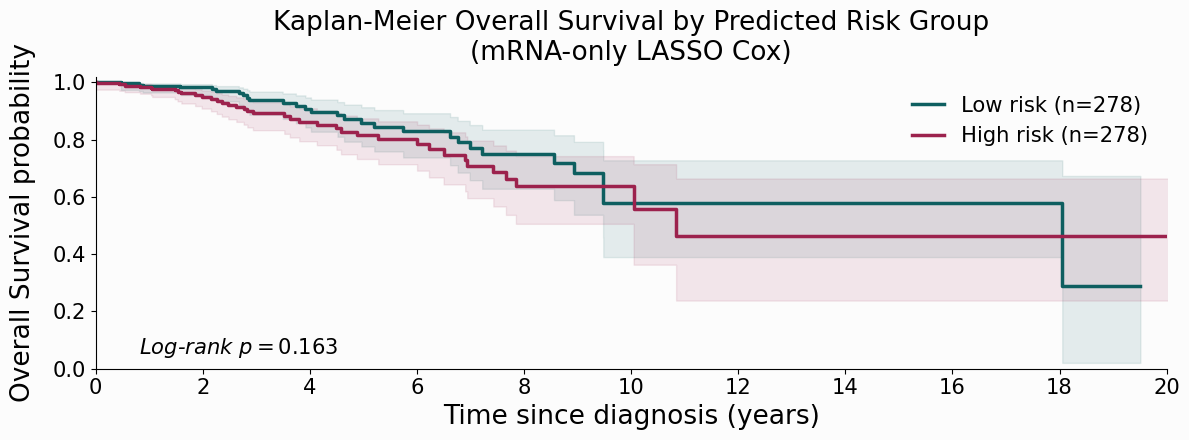

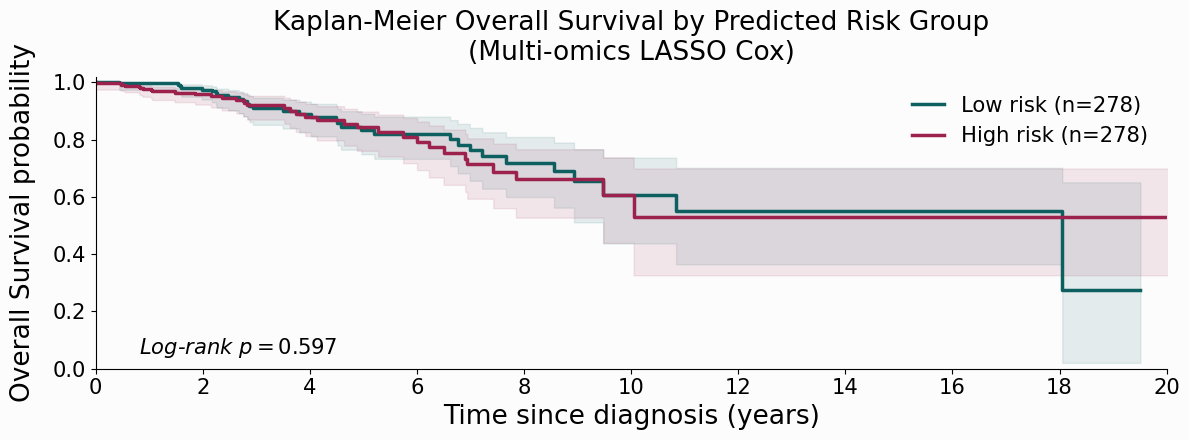

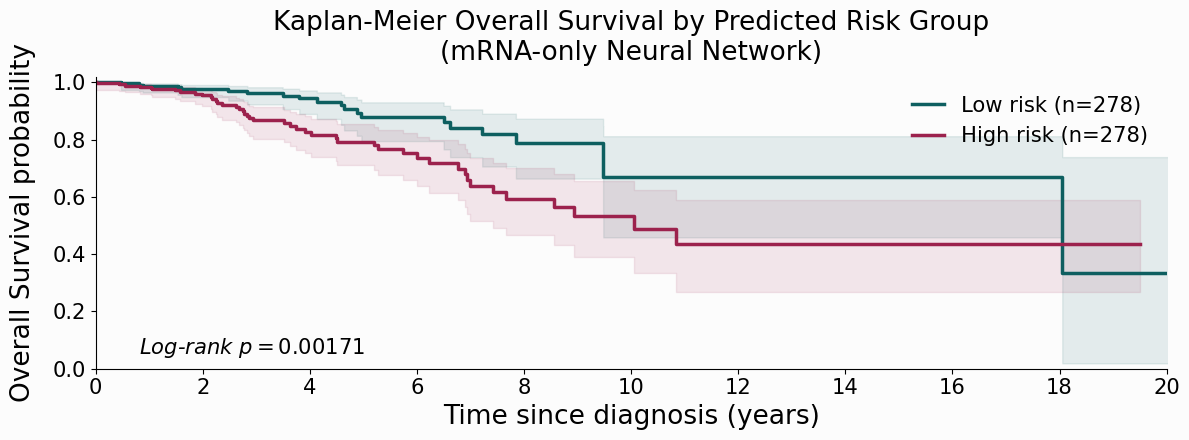

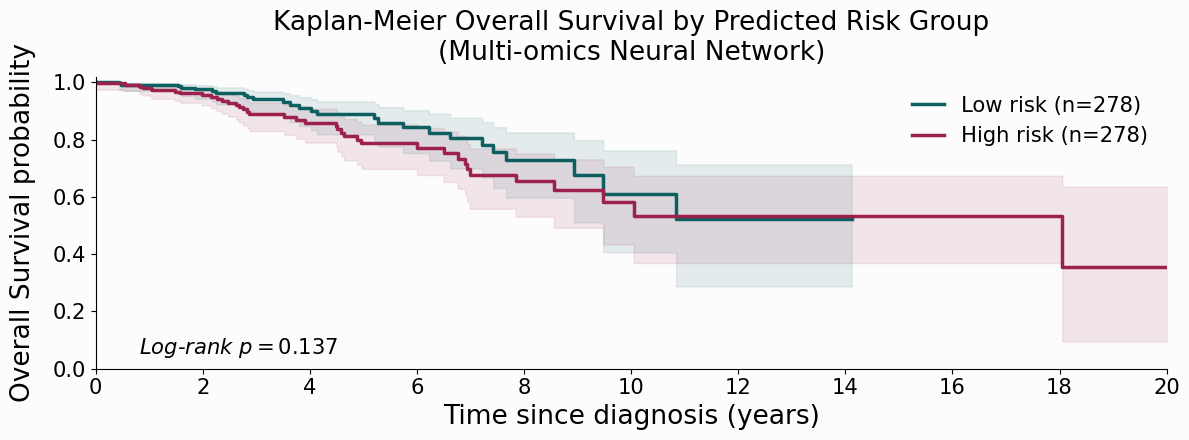

In [21]:
# Kaplan-Meier survival split by predicted risk (median cut)
km_files = {
    "mRNA-only LASSO Cox":   "../results/tables/lasso_cox_mrna_risk_scores.csv",
    "Multi-omics LASSO Cox": "../results/tables/lasso_cox_multiomics_risk_scores.csv",
    "mRNA-only Neural Network":      "../results/tables/nn_mrna_only_risk_scores.csv",
    "Multi-omics Neural Network":    "../results/tables/nn_integrated_risk_scores.csv",
}

TEXT_SIZE = 19
BLUE = "#0e5f60"
PINK = "#9c224d"
BG = "#fcfcfc"

km_results = []

for model_name, fpath in km_files.items():

    if not Path(fpath).exists():
        print(f"Skipping {model_name} — {fpath} not found")
        continue

    scores = pd.read_csv(fpath)

    scores = (
        scores
        .drop_duplicates(subset="patient", keep="last")
        .set_index("patient")
    )

    common = scores.index.intersection(surv.index)

    d = surv.loc[common].copy()
    d["risk_score"] = scores.loc[common, "risk_score"]
    d["time_years"] = d["time"] / 365.25

    median_risk = d["risk_score"].median()

    # high/low split at the median predicted risk
    d["risk_group"] = np.where(
        d["risk_score"] >= median_risk,
        "High risk",
        "Low risk"
    )

    low = d[d["risk_group"] == "Low risk"]
    high = d[d["risk_group"] == "High risk"]

    lr = logrank_test(
        low["time_years"],
        high["time_years"],
        event_observed_A=low["event"],
        event_observed_B=high["event"]
    )

    fig, ax = plt.subplots(
        figsize=(12, 4.5),
        facecolor=BG
    )

    ax.set_facecolor(BG)

    kmf = KaplanMeierFitter()

    group_settings = [
        ("Low risk", low, BLUE),
        ("High risk", high, PINK)
    ]

    for group_name, sub, color in group_settings:

        kmf.fit(
            durations=sub["time_years"],
            event_observed=sub["event"],
            label=f"{group_name} (n={len(sub)})"
        )

        kmf.plot_survival_function(
            ax=ax,
            ci_show=True,
            color=color,
            linewidth=2.5,
            show_censors=False,
            ci_alpha=0.1
        )

    ax.set_title(
        f"Kaplan-Meier Overall Survival by Predicted Risk Group\n({model_name})",
        fontsize=TEXT_SIZE,
        pad=12
    )

    ax.set_xlabel(
        "Time since diagnosis (years)",
        fontsize=TEXT_SIZE
    )

    ax.set_ylabel(
        "Overall Survival probability",
        fontsize=TEXT_SIZE,
        labelpad=12
    )

    ax.set_ylim(0, 1.02)

    ax.set_xlim(0, 20)
    ax.xaxis.set_major_locator(MultipleLocator(2))

    if lr.p_value < 0.0001:
        p_text = r"Log-rank $p < 0.0001$"
    else:
        p_text = rf"Log-rank $p = {lr.p_value:.3g}$"

    ax.text(
        0.04,
        0.05,
        p_text,
        transform=ax.transAxes,
        fontsize=TEXT_SIZE * 0.8,
        style="italic"
    )

    ax.legend(
        loc="upper right",
        frameon=False,
        fontsize=TEXT_SIZE * 0.8,
        handlelength=1.5
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=TEXT_SIZE * 0.8
    )

    plt.tight_layout()

    fname = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    plt.savefig(
        f"../results/figures/km_risk_groups_{fname}.png",
        dpi=300,
        facecolor=BG,
        bbox_inches="tight"
    )

    plt.show()

    km_results.append({
        "model": model_name,
        "logrank_p": round(lr.p_value, 4),
        "n_high": len(high),
        "n_low": len(low)
    })

if km_results:
    km_df = pd.DataFrame(km_results)

    km_df.to_csv(
        "../results/tables/km_risk_group_logrank.csv",
        index=False
    )

In [22]:
# number-at-risk table for the last KM plot
if km_results:

    risk_times = np.arange(0, 21, 2)

    def number_at_risk(group_df, times):
        return [
            (group_df["time_years"] >= t).sum()
            for t in times
        ]

    low_counts = number_at_risk(low, risk_times)
    high_counts = number_at_risk(high, risk_times)

    risk_times = np.arange(0, 21, 2)

    risk_table = pd.DataFrame({
        "Risk group": ["Low risk", "High risk"]
    })

    for t in risk_times:
        risk_table[f"{t:g} years"] = [
            (low["time_years"] >= t).sum(),
            (high["time_years"] >= t).sum()
        ]

    risk_table.to_csv(
        f"../results/tables/km_risk_table_{fname}.csv",
        index=False
    )

    print(risk_table)

  Risk group  0 years  2 years  4 years  6 years  8 years  10 years  12 years  \
0   Low risk      278      160       87       49       26         7         3   
1  High risk      278      155       81       48       27        13         7   

   14 years  16 years  18 years  20 years  
0         1         0         0         0  
1         6         4         3         1  


In [23]:
# pull everything together into the final comparison table
report_table = summary.copy()
report_table.columns = ["Model", "Mean C-index", "SD", "Min", "Max"]

km_path = Path("../results/tables/km_risk_group_logrank.csv")
if km_path.exists():
    km_df = pd.read_csv(km_path)
    # KM results use the long model names; map them to the short names used above
    name_map = {
        "mRNA-only LASSO Cox":        "mRNA-only LASSO",
        "Multi-omics LASSO Cox":      "Multi-omics LASSO",
        "mRNA-only Neural Network":   "mRNA-only NN",
        "Multi-omics Neural Network": "Multi-omics NN",
    }
    km_df["Model"] = km_df["model"].map(name_map)
    report_table = report_table.merge(
        km_df[["Model", "logrank_p"]].rename(columns={"logrank_p": "KM log-rank p"}),
        on="Model", how="left")
else:
    print("KM results not found - run models 11/12/NN to generate the four "
          "*_risk_scores.csv files, then re-run section 2. "
          "Showing performance summary without the KM column.\n")

report_table.to_csv("../results/tables/final_model_comparison_table.csv", index=False)
print(report_table.to_string(index=False))

            Model  Mean C-index    SD   Min   Max  KM log-rank p
  mRNA-only LASSO         0.576 0.078 0.495 0.684         0.1632
Multi-omics LASSO         0.585 0.105 0.432 0.701         0.5970
     mRNA-only NN         0.621 0.056 0.563 0.710         0.0017
   Multi-omics NN         0.640 0.195 0.311 0.831         0.1368
